In [ ]:
import json
import os
import torch
import numpy as np
import torch
from torch.utils.data import DataLoader
import time
import resource
import json
import torch
import os
import subprocess
import sys

Load parameters

In [2]:
class JSONConfigLoader:
    def __init__(self, config_file):
        self.config_file = config_file
    
    def get_args(self):
        with open(self.config_file, 'r') as f:
            config_dict = json.load(f)
        
        args = type('Args', (), {})()
        
        for key, value in config_dict.items():
            setattr(args, key, value)
        
        if args.device == "cuda:0" and not torch.cuda.is_available():
            args.device = "cpu"
            print("CUDA not available, using CPU instead")

        os.makedirs(args.save_dir, exist_ok=True)
        os.makedirs('./model/', exist_ok=True)
        os.makedirs('./Decoder/', exist_ok=True)
        
        return args

config_file = "./参数/HER2ST/D1.json" 
loader = JSONConfigLoader(config_file)
args = loader.get_args()

Training

In [3]:
print("run main.py...")
main_script_path = "./main.py"

# 构建命令行参数
cmd_args = [sys.executable, main_script_path]

# 动态添加所有args参数
for key, value in vars(args).items():
    cmd_args.extend([f"--{key}", str(value)])

try:
    result = subprocess.run(cmd_args, check=True)
except subprocess.CalledProcessError as e:
    print(f"running error: {e}")
except Exception as e:
    print(f"other error: {e}")

run main.py...
start time: 1759990502.608865 s
D1
Namespace(dataset='Her2st', dataset_dir='/data/dataset/ST/her2st-master/data', img_dir='/data/dataset/ST/her2st-master/data/ST-imgs/D/D1/10426_HE_BT_C1.jpg', patch_size=56, label_available=False, is_10x=False, countfile_name='', slice_name='D1', graph_type='KNN', rad_cutoff=None, k_cutoff=6, subgraph_neighbors=[6, 6], gene_in_dim=3000, gene_hidden_dim=512, gene_out_dim=128, gene_num_layers=2, gene_augtype='noise', gene_mask_pct=0.1, gene_sigma_noise=1, img_sigma_noise=50, neg_type='others_label', img_out_dim=128, fc_dim=[128], hidden_dim=128, mlp_layers=2, p=1.0, p_round=1, iter_epochs=50, tau=0.07, batch_size=60, num_epochs=50, lr=0.01, device='cuda:0', alpha=1.0, clone=3, internal=3, alpha_lr=0.25, reawrd_alphalr=1, reawrd_emdklr=1, emb_weight=1.0, k=6, valid_cluster=3, gene_only=False, img_only=False, pseudo_cluster=3, save_dir='./output/Her2st/D1/', img_feat=None, is_first=True)
Preprocessing gene expression matrix...
Preprocessing 

  0%|          | 0/50 [00:00<?, ?it/s]

Initializing negpool...


100%|██████████| 50/50 [16:14<00:00, 19.49s/it]


start memory: 523780 KB
end memory: 6263328 KB
used time: 986.91708111763 s
used memory: 5739548 KB


Visualization

ARI: 0.616268


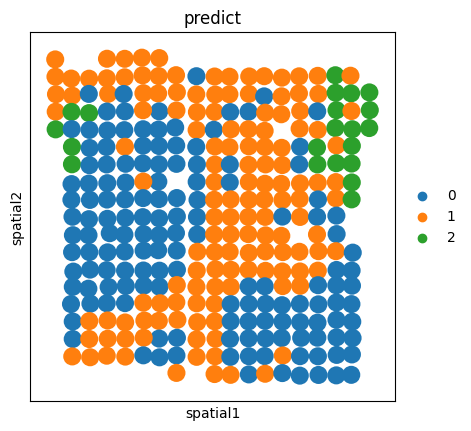

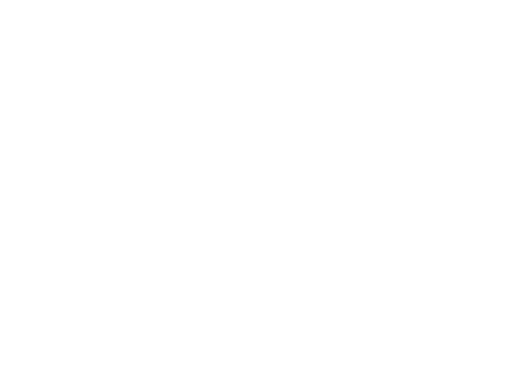

In [8]:
import anndata
import scanpy as sc
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from collections import Counter
from sklearn.metrics import adjusted_rand_score
import anndata
import matplotlib.pyplot as plt


def plot_spa_cluter_result(adata, title='', color="predict", save_root=None, is_10x=False, size=4):

    if not is_10x:
        sc.pl.spatial(adata, color=color, img_key=None, spot_size=300, scale_factor=1.0)
    else:
        sc.pl.spatial(adata, color=color, img_key="hires", size=size)
    
    plt.title(title)
    plt.axis('off')
    if save_root:
        plt.savefig(save_root)
    plt.show()
    return

adata = anndata.read_h5ad("./output/Her2st/D1/D1_adata.h5ad")
obs_df = adata.obs.dropna()
ari = adjusted_rand_score(obs_df['label'], obs_df['predict'].cat.codes)

# 打印 ARI
print("ARI: %.6f" % ari)
title = "SpaConTDS: ARI=%.6f" % (ari)
# 绘制空间聚类结果
plot_spa_cluter_result(adata)


Refine

ARI: 0.740198


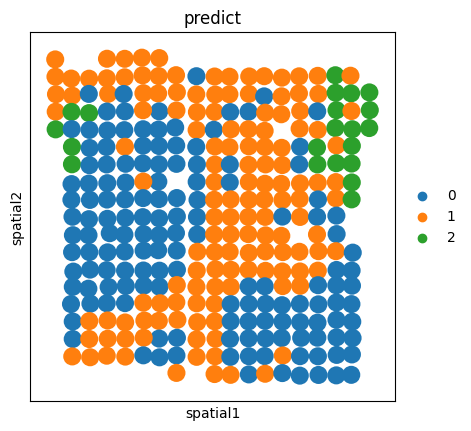

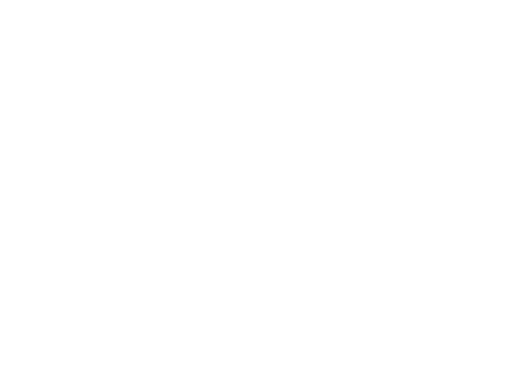

In [12]:

def refine_clusters(adata, r):

    X = adata.obsm['spatial']  
    labels = adata.obs['predict'].values

    nbrs = NearestNeighbors(radius=r)
    nbrs.fit(X)
    
    refined_labels = labels.copy() 
    for i in range(len(X)):
        indices = nbrs.radius_neighbors([X[i]], return_distance=False)[0]

        neighbor_labels = labels[indices]
        most_common_label = Counter(neighbor_labels).most_common(1)[0][0]

        refined_labels[i] = most_common_label

    adata.obs['refined_cluster'] = pd.Categorical(refined_labels)

refine_clusters(adata, r=700)

obs_df = adata.obs.dropna()
ari = adjusted_rand_score(obs_df['label'], obs_df['refined_cluster'].cat.codes)

# 打印 ARI
print("ARI: %.6f" % ari)
title = "SpaConTDS: ARI=%.6f" % (ari)

plot_spa_cluter_result(adata)
